<a href="https://colab.research.google.com/github/PramitGhosh02/DAA-LAB/blob/main/Fake_News_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

FAKE NEWS PREDICTION-

BERT

------------------------------------------------------------------

In [ ]:
import pandas as pd

In [ ]:
from google.colab import files

df_fake = files.upload()

df_true =  files.upload()

Saving Fake.csv to Fake (1).csv


Saving True.csv to True (1).csv


In [ ]:
df_fake["Label"] = "Fake"
df_true["Label"] = "True"

In [ ]:
fake_filename = list(df_fake.keys())[0]
true_filename = list(df_true.keys())[0]
df_fake_data = pd.read_csv(fake_filename)
df_true_data = pd.read_csv(true_filename)
df_fake_data["Label"] = "Fake"
df_true_data["Label"] = "True"
df = pd.concat([df_fake_data, df_true_data])
df = df.sample(frac=1).reset_index(drop=True)

In [ ]:
df.head(5)

,title,text,subject,date,Label,text_length,Label_enc
0,CNN FIRES BLACK DEM Party Chair: New Wikileaks...,You just can t make this up! CNN fires black D...,politics,"Oct 31, 2016",Fake,1994,0
1,"Clinton calls Trump a 'loose cannon,' risky ch...",WASHINGTON (Reuters) - U.S. Democratic preside...,politicsNews,"May 4, 2016",True,2327,1
2,China says opposes unilateral sanctions after ...,BEIJING (Reuters) - China s Foreign Ministry s...,worldnews,"November 22, 2017",True,266,1
3,Chris Wallace Gets NC Governor To Admit That ...,Fox host Chris Wallace pinned bigoted North Ca...,News,"May 8, 2016",Fake,3457,0
4,North Korea tests short-range missiles as Sout...,SEOUL/WASHINGTON (Reuters) - North Korea fired...,worldnews,"August 25, 2017",True,5180,1


In [ ]:
df.isnull().sum()

,0
title,0
text,0
subject,0
date,0
Label,0


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

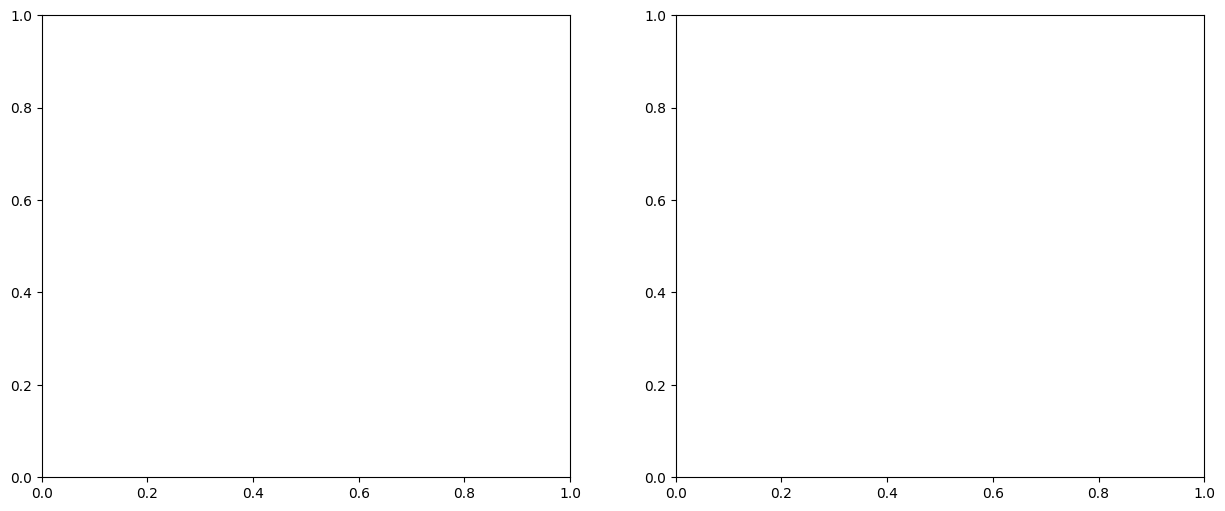

In [ ]:
fig, axes = plt.subplots(1,2, figsize = (15,6))

In [ ]:
sns.histplot(df_fake_data.subject, palette = 'Set1', alpha = 0.5, ax = axes[0])
axes[0].tick_params(axis = 'x', rotation = 90)
axes[0].set_title('Fake News Subject')

/tmp/ipython-input-1045253578.py:1: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(df_fake_data.subject, palette = 'Set1', alpha = 0.5, ax = axes[0])


Text(0.5, 1.0, 'Fake News Subject')

In [ ]:
sns.histplot(df_true_data.subject, palette = 'Set1', alpha = 0.5, ax = axes[1])
axes[1].tick_params(axis = 'x', rotation = 90)
axes[1].set_title('True  News Subject')

/tmp/ipython-input-2523131044.py:1: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(df_true_data.subject, palette = 'Set1', alpha = 0.5, ax = axes[1])


Text(0.5, 1.0, 'True  News Subject')

In [ ]:
print("Fake News Subject : ",dict(df_fake_data.subject.value_counts()))
print("True News Subject : ",dict(df_true_data.subject.value_counts()))

Fake News Subject :  {'News': np.int64(9050), 'politics': np.int64(6841), 'left-news': np.int64(4459), 'Government News': np.int64(1570), 'US_News': np.int64(783), 'Middle-east': np.int64(778)}
True News Subject :  {'politicsNews': np.int64(11272), 'worldnews': np.int64(10145)}


/tmp/ipython-input-1559254166.py:1: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(df.Label, palette = 'Set1', alpha = 0.5)


,count
Label,
Fake,23481
True,21417


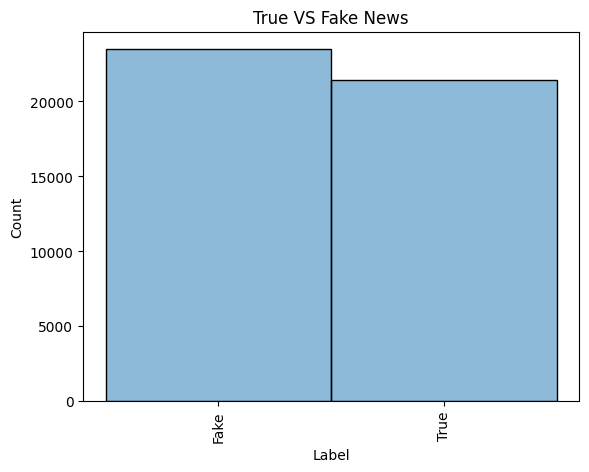

In [ ]:
sns.histplot(df.Label, palette = 'Set1', alpha = 0.5)
plt.tick_params(axis = 'x', rotation = 90)
plt.title('True VS Fake News')
df.Label.value_counts()

In [ ]:
df["text"] = df["title"]+df["text"]

In [ ]:
df['Label'] = df['Label'].map({'True':1, 'Fake':0})

In [ ]:
from sklearn.model_selection import train_test_split

X = df['text']
y = df['Label']

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify = y, test_size = 0.2, random_state = 10)

In [ ]:
!pip install transformers torch scikit-learn networkx matplotlib python-louvain


In [ ]:
from transformers import AutoTokenizer, AutoModel
import torch
import numpy as np

MODEL = "sentence-transformers/all-MiniLM-L6-v2"
tokenizer = AutoTokenizer.from_pretrained(MODEL)
model = AutoModel.from_pretrained(MODEL)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

def embed_texts(texts, batch_size=32):
    embeddings = []
    with torch.no_grad():
        for i in range(0, len(texts), batch_size):
            batch = texts[i:i+batch_size]
            enc = tokenizer(batch, padding=True, truncation=True, return_tensors="pt").to(device)
            out = model(**enc, return_dict=True)
            mask = enc["attention_mask"].unsqueeze(-1)
            last_hidden = out.last_hidden_state
            mean_pooled = (last_hidden * mask).sum(1) / mask.sum(1)
            embeddings.append(mean_pooled.cpu().numpy())
    return np.vstack(embeddings)


In [ ]:

import pandas as pd
import numpy as np
from sentence_transformers import SentenceTransformer
import torch
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

df = df.dropna(subset=["text"])

fake_texts = df[df["Label"] == "Fake"]["text"].astype(str).tolist()[:500]
true_texts = df[df["Label"] == "True"]["text"].astype(str).tolist()[:500]

print("Fake samples:", len(fake_texts))
print("True samples:", len(true_texts))

model = SentenceTransformer('all-MiniLM-L6-v2', device=device)

def embed_in_batches(texts, model, batch_size=32):
    embeddings = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        if len(batch) == 0:
            continue
        emb = model.encode(batch, show_progress_bar=False)
        embeddings.append(emb)
    if len(embeddings) == 0:
        return np.array([])
    return np.vstack(embeddings)

fake_emb = embed_in_batches(fake_texts, model)
true_emb = embed_in_batches(true_texts, model)

print("Fake embeddings shape:", fake_emb.shape)
print("True embeddings shape:", true_emb.shape)


Using device: cpu
Fake samples: 0
True samples: 0
Fake embeddings shape: (0,)
True embeddings shape: (0,)


In [ ]:
print("Fake data columns:", df_fake_data.columns)
print("True data columns:", df_true_data.columns)


Fake data columns: Index(['title', 'text', 'subject', 'date', 'Label'], dtype='object')
True data columns: Index(['title', 'text', 'subject', 'date', 'Label'], dtype='object')


In [ ]:
df_fake_data["Label"] = "Fake"
df_true_data["Label"] = "True"

df = pd.concat([df_fake_data, df_true_data])
df = df.sample(frac=1).reset_index(drop=True)


In [ ]:
fake_texts = df[df["Label"] == "Fake"]["text"].dropna().tolist()[:500]
true_texts = df[df["Label"] == "True"]["text"].dropna().tolist()[:500]

print("Fake sample count:", len(fake_texts))
print("True sample count:", len(true_texts))


Fake sample count: 500
True sample count: 500


In [ ]:
from sentence_transformers import SentenceTransformer
import numpy as np

model = SentenceTransformer("all-MiniLM-L6-v2")

def embed_in_batches(texts, model, batch_size=64):
    embeddings = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        emb = model.encode(batch, convert_to_numpy=True, show_progress_bar=True)
        embeddings.append(emb)
    return np.vstack(embeddings)

fake_emb = embed_in_batches(fake_texts, model)
true_emb = embed_in_batches(true_texts, model)

print("Fake emb shape:", fake_emb.shape)
print("True emb shape:", true_emb.shape)


Batches:   0%|          | 0/2 [00:00<?, ?it/s]

Batches:   0%|          | 0/2 [00:00<?, ?it/s]

Batches:   0%|          | 0/2 [00:00<?, ?it/s]

Batches:   0%|          | 0/2 [00:00<?, ?it/s]

Batches:   0%|          | 0/2 [00:00<?, ?it/s]

...

Batches:   0%|          | 0/2 [00:00<?, ?it/s]

Batches:   0%|          | 0/2 [00:00<?, ?it/s]

Batches:   0%|          | 0/2 [00:00<?, ?it/s]

Batches:   0%|          | 0/2 [00:00<?, ?it/s]

Fake emb shape: (500, 384)
True emb shape: (500, 384)


In [ ]:
print("Fake emb shape:", fake_emb.shape)
print("True emb shape:", true_emb.shape)


Fake emb shape: (500, 384)
True emb shape: (500, 384)


In [ ]:
from sklearn.neighbors import kneighbors_graph
import networkx as nx

def build_knn_graph(embeddings, k=5):
    knn_graph = kneighbors_graph(embeddings, k, mode='connectivity', include_self=False)
    G = nx.from_scipy_sparse_array(knn_graph)
    return G

fake_graph = build_knn_graph(fake_emb, k=5)
true_graph = build_knn_graph(true_emb, k=5)

print("Fake graph nodes:", fake_graph.number_of_nodes())
print("True graph nodes:", true_graph.number_of_nodes())


Fake graph nodes: 500
True graph nodes: 500


In [ ]:
def analyze_graph(graph):
    analysis = {
        "Nodes": graph.number_of_nodes(),
        "Edges": graph.number_of_edges(),
        "Average Clustering": nx.average_clustering(graph),
        "Average Degree": sum(dict(graph.degree()).values()) / graph.number_of_nodes(),
        "Connected Components": nx.number_connected_components(graph)
    }
    return analysis

fake_analysis = analyze_graph(fake_graph)
true_analysis = analyze_graph(true_graph)

print("Fake News Graph Analysis:")
print(fake_analysis)
print("\nTrue News Graph Analysis:")
print(true_analysis)


Fake News Graph Analysis:
{'Nodes': 500, 'Edges': 1984, 'Average Clustering': 0.24618328079313676, 'Average Degree': 7.936, 'Connected Components': 2}

True News Graph Analysis:
{'Nodes': 500, 'Edges': 1846, 'Average Clustering': 0.3308420372204933, 'Average Degree': 7.384, 'Connected Components': 1}


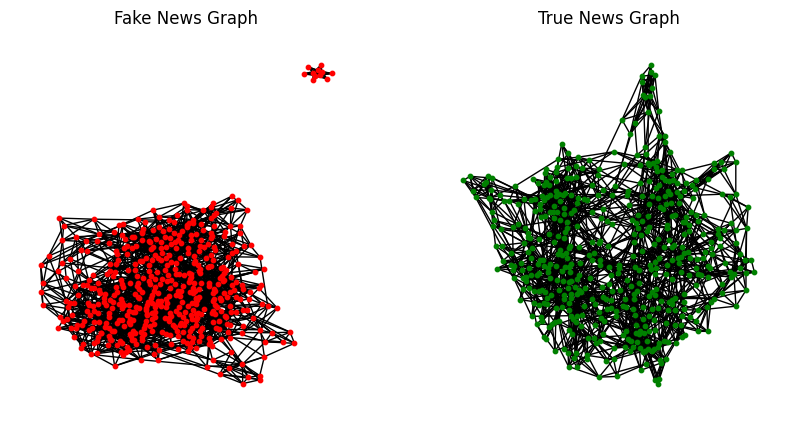

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
nx.draw(fake_graph, node_size=10, node_color='red')
plt.title("Fake News Graph")

plt.subplot(1,2,2)
nx.draw(true_graph, node_size=10, node_color='green')
plt.title("True News Graph")

plt.show()


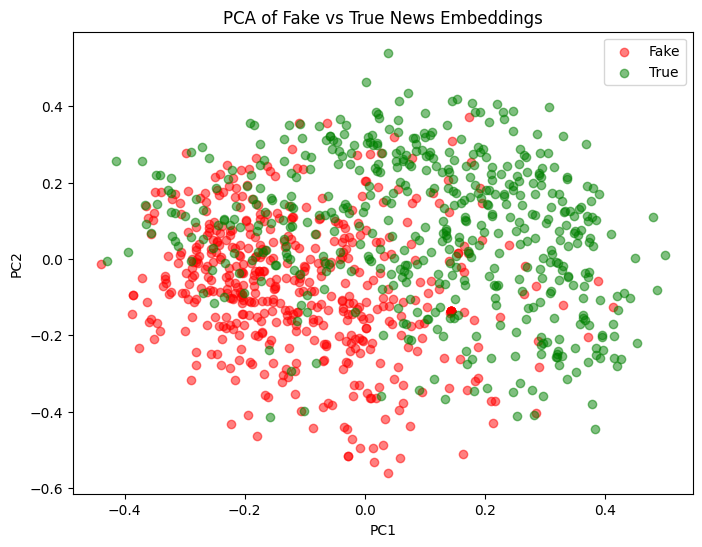

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
all_emb = np.vstack([fake_emb, true_emb])
labels = ["Fake"]*fake_emb.shape[0] + ["True"]*true_emb.shape[0]
pca = PCA(n_components=2)
pca_result = pca.fit_transform(all_emb)

plt.figure(figsize=(8,6))
plt.scatter(pca_result[:fake_emb.shape[0],0], pca_result[:fake_emb.shape[0],1], c='red', label='Fake', alpha=0.5)
plt.scatter(pca_result[fake_emb.shape[0]:,0], pca_result[fake_emb.shape[0]:,1], c='green', label='True', alpha=0.5)
plt.title("PCA of Fake vs True News Embeddings")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.show()


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


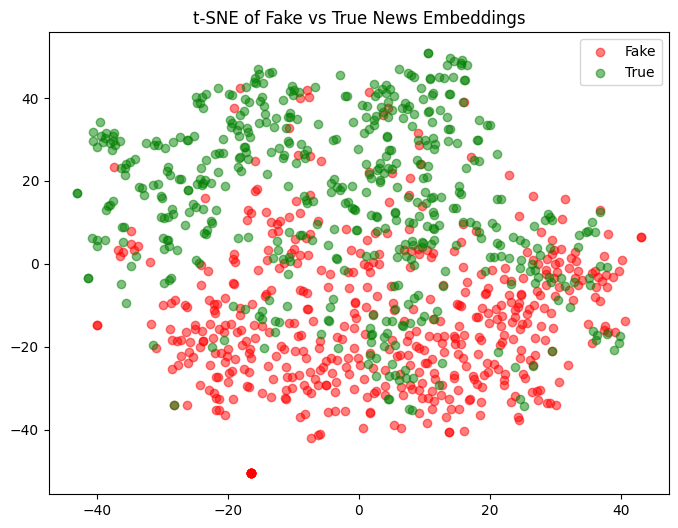

In [ ]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, perplexity=30, random_state=42, n_iter=1000)
tsne_result = tsne.fit_transform(all_emb)

plt.figure(figsize=(8,6))
plt.scatter(tsne_result[:fake_emb.shape[0],0], tsne_result[:fake_emb.shape[0],1], c='red', label='Fake', alpha=0.5)
plt.scatter(tsne_result[fake_emb.shape[0]:,0], tsne_result[fake_emb.shape[0]:,1], c='green', label='True', alpha=0.5)
plt.title("t-SNE of Fake vs True News Embeddings")
plt.legend()
plt.show()


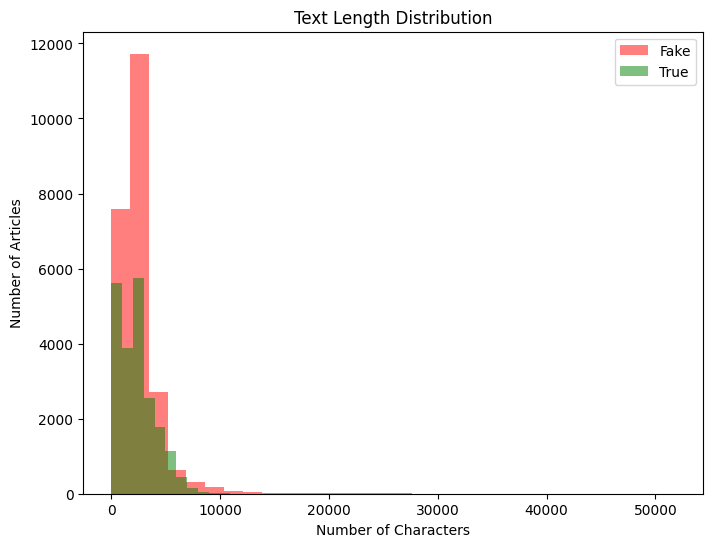

In [ ]:
df['text_length'] = df['text'].astype(str).apply(len)

plt.figure(figsize=(8,6))
plt.hist(df[df['Label']=='Fake']['text_length'], bins=30, alpha=0.5, color='red', label='Fake')
plt.hist(df[df['Label']=='True']['text_length'], bins=30, alpha=0.5, color='green', label='True')
plt.title("Text Length Distribution")
plt.xlabel("Number of Characters")
plt.ylabel("Number of Articles")
plt.legend()
plt.show()


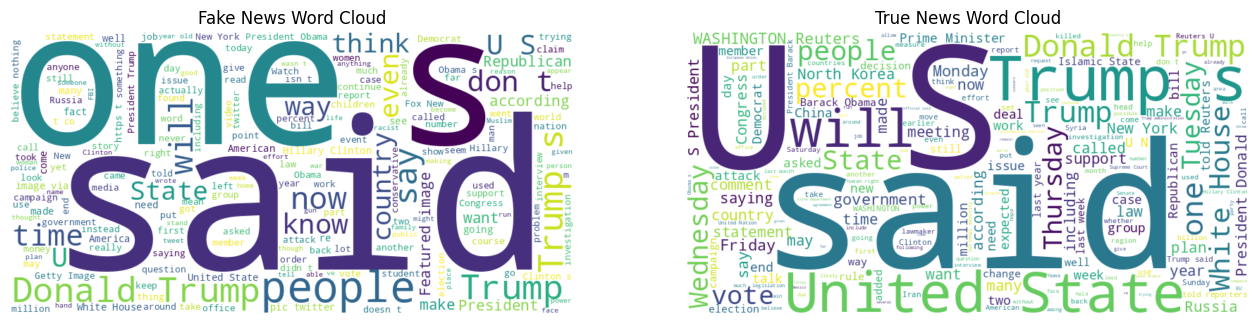

In [ ]:
from wordcloud import WordCloud

fake_text = " ".join(df[df['Label']=='Fake']['text'].astype(str).tolist())
true_text = " ".join(df[df['Label']=='True']['text'].astype(str).tolist())

fake_wc = WordCloud(width=800, height=400, background_color='white').generate(fake_text)
true_wc = WordCloud(width=800, height=400, background_color='white').generate(true_text)

plt.figure(figsize=(16,6))
plt.subplot(1,2,1)
plt.imshow(fake_wc, interpolation='bilinear')
plt.axis('off')
plt.title("Fake News Word Cloud")

plt.subplot(1,2,2)
plt.imshow(true_wc, interpolation='bilinear')
plt.axis('off')
plt.title("True News Word Cloud")
plt.show()


In [ ]:
from sentence_transformers import SentenceTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd
text_column = 'text'

le = LabelEncoder()
df['Label_enc'] = le.fit_transform(df['Label'])

X = df[text_column].tolist()
y = df['Label_enc'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = SentenceTransformer('all-MiniLM-L6-v2')
X_train_emb = model.encode(X_train, convert_to_numpy=True, show_progress_bar=True)
X_test_emb = model.encode(X_test, convert_to_numpy=True, show_progress_bar=True)

clf = LogisticRegression(max_iter=1000)
clf.fit(X_train_emb, y_train)

probs = clf.predict_proba(X_test_emb)[:, 1]
preds = clf.predict(X_test_emb)

df_results = pd.DataFrame({
    'Text': list(X_test),
    'Actual': le.inverse_transform(y_test),
    'Predicted': le.inverse_transform(preds),
    'Prob_True': probs,
    'Prob_Fake': 1 - probs
})

df_results.reset_index(drop=True, inplace=True)


Batches:   0%|          | 0/1123 [00:00<?, ?it/s]

Batches:   0%|          | 0/281 [00:00<?, ?it/s]

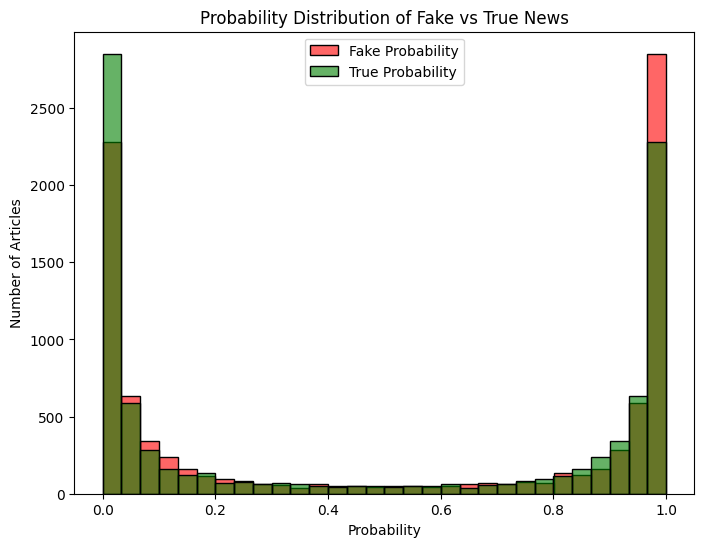

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.histplot(df_results['Prob_Fake'], bins=30, color='red', alpha=0.6, label='Fake Probability')
sns.histplot(df_results['Prob_True'], bins=30, color='green', alpha=0.6, label='True Probability')
plt.xlabel("Probability")
plt.ylabel("Number of Articles")
plt.title("Probability Distribution of Fake vs True News")
plt.legend()
plt.show()


In [ ]:
top_fake = df_results.sort_values('Prob_Fake', ascending=False).head(10)
top_true = df_results.sort_values('Prob_True', ascending=False).head(10)

print("Top Fake News Predictions:\n", top_fake[['Text','Prob_Fake']])
print("\nTop True News Predictions:\n", top_true[['Text','Prob_True']])


Top Fake News Predictions:
                                                    Text  Prob_Fake
8696  Tune in to the Alternate Current Radio Network...   0.999993
7312  Every once in a while, we are introduced to an...   0.999992
8389  Remember that cute scene in the movie Love Act...   0.999990
6476  Hysterical! As always, conservative comedian S...   0.999987
3575  If there s one thing that  put the stupidity o...   0.999985
6545  The media is in an all out frenzy today, as th...   0.999984
539   Recently, Michelle Obama posed for InStyle mag...   0.999983
7729  President Obama has done something that no oth...   0.999982
4744  What a nut job! A 10th-grade teacher invited r...   0.999977
3861  If this isn t white guilt on steroids and indo...   0.999977

Top True News Predictions:
                                                    Text  Prob_True
6115  TOKYO (Reuters) - Japanese Deputy Prime Minist...   0.999905
3855  NAIROBI (Reuters) - The Kenyan election board ...   0.999900
4313 

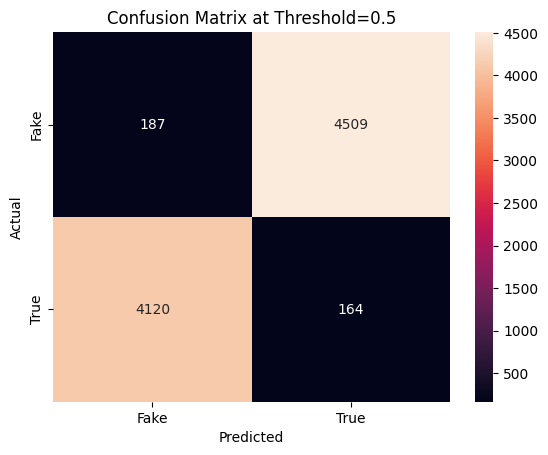

In [ ]:
from sklearn.metrics import confusion_matrix

threshold = 0.5
pred_label = (df_results['Prob_Fake'] > threshold).astype(int)
cm = confusion_matrix(y_test, pred_label)

sns.heatmap(cm, annot=True, fmt="d", xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix at Threshold={threshold}")
plt.show()


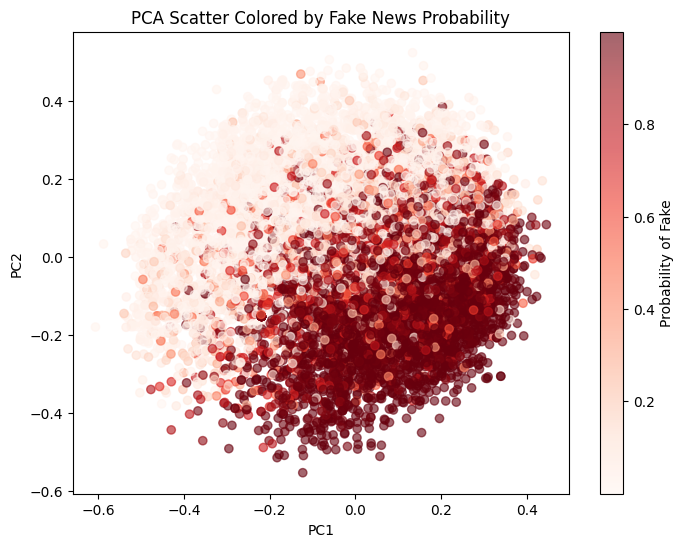

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_test_emb)

plt.figure(figsize=(8,6))
plt.scatter(pca_result[:,0], pca_result[:,1],
            c=df_results['Prob_Fake'], cmap='Reds', alpha=0.6)
plt.colorbar(label='Probability of Fake')
plt.title("PCA Scatter Colored by Fake News Probability")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()


In [ ]:
df_results.to_csv("fake_news_predictions_with_probs.csv", index=False)


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

y_true = df_results['Actual'].map({'Fake':0, 'True':1}).values
y_pred = df_results['Predicted'].map({'Fake':0, 'True':1}).values

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

metrics = {'Accuracy': accuracy, 'Precision': precision, 'Recall': recall, 'F1-score': f1}



In [ ]:
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)


Accuracy: 0.960913140311804
Precision: 0.9565823078709078
Recall: 0.96171802054155
F1-score: 0.9591432894890001


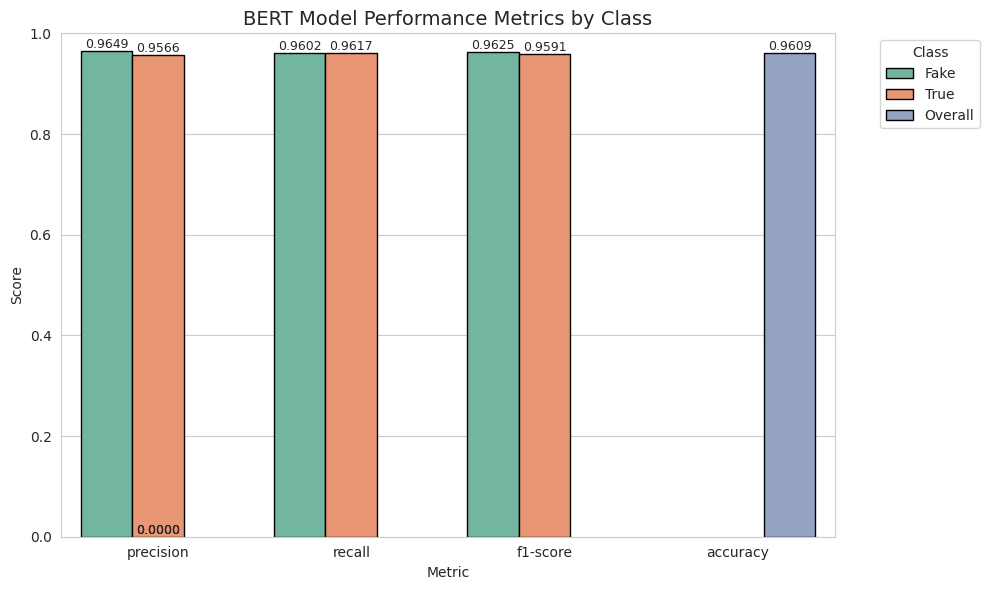

In [ ]:
plt.figure(figsize=(10,6))
sns.set_style("whitegrid")

bar_plot = sns.barplot(
    x='Metric',
    y='Score',
    hue='Class',
    data=metrics_df,
    palette='Set2',
    edgecolor='black'
)

for p in bar_plot.patches:
    height = p.get_height()
    bar_plot.annotate(
        f'{height:.4f}',
        (p.get_x() + p.get_width() / 2., height),
        ha='center', va='bottom', fontsize=9
    )

plt.ylim(0,1)
plt.title("BERT Model Performance Metrics by Class", fontsize=14)
plt.ylabel("Score")
plt.xlabel("Metric")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Class')
plt.tight_layout()
plt.show()


LSTM

----------------------------------------------------

In [ ]:
import pandas as pd

In [ ]:
from google.colab import files

df_fake = files.upload()

df_true =  files.upload()

Saving Fake.csv to Fake (2).csv


Saving True.csv to True (2).csv


In [ ]:
import pandas as pd

fake_filename = list(df_fake.keys())[0]
true_filename = list(df_true.keys())[0]

df_fake_data = pd.read_csv(fake_filename)
df_true_data = pd.read_csv(true_filename)

df_fake_data['Label'] = 'Fake'
df_true_data['Label'] = 'True'

df = pd.concat([df_fake_data, df_true_data]).sample(frac=1).reset_index(drop=True)


In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

le = LabelEncoder()
df['Label_enc'] = le.fit_transform(df['Label'])

X = df['text'].tolist()
y = df['Label_enc'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_words = 10000  # max vocabulary size
max_len = 200      # max sequence length

tokenizer = Tokenizer(num_words=max_words, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding='post')


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional

embedding_dim = 100

model = Sequential([
    Embedding(input_dim=max_words, output_dim=embedding_dim, input_length=max_len),
    Bidirectional(LSTM(128, return_sequences=False)),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [ ]:
history = model.fit(
    X_train_pad, y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.1
)


Epoch 1/5
506/506 ━━━━━━━━━━━━━━━━━━━━ 415s 797ms/step - accuracy: 0.8882 - loss: 0.2400 - val_accuracy: 0.9875 - val_loss: 0.0458
Epoch 2/5
506/506 ━━━━━━━━━━━━━━━━━━━━ 389s 768ms/step - accuracy: 0.9934 - loss: 0.0214 - val_accuracy: 0.9858 - val_loss: 0.0555
Epoch 3/5
506/506 ━━━━━━━━━━━━━━━━━━━━ 388s 766ms/step - accuracy: 0.9952 - loss: 0.0158 - val_accuracy: 0.9850 - val_loss: 0.0485
Epoch 4/5
506/506 ━━━━━━━━━━━━━━━━━━━━ 381s 753ms/step - accuracy: 0.9979 - loss: 0.0075 - val_accuracy: 0.9900 - val_loss: 0.0391
Epoch 5/5
506/506 ━━━━━━━━━━━━━━━━━━━━ 379s 749ms/step - accuracy: 0.9992 - loss: 0.0031 - val_accuracy: 0.9908 - val_loss: 0.0393


In [ ]:
probs = model.predict(X_test_pad).flatten()  # probability of class True
preds = (probs > 0.5).astype(int)           # threshold 0.5

df_results = pd.DataFrame({
    'Text': X_test,
    'Actual': le.inverse_transform(y_test),
    'Predicted': le.inverse_transform(preds),
    'Prob_True': probs,
    'Prob_Fake': 1 - probs
})

df_results.reset_index(drop=True, inplace=True)


281/281 ━━━━━━━━━━━━━━━━━━━━ 41s 146ms/step


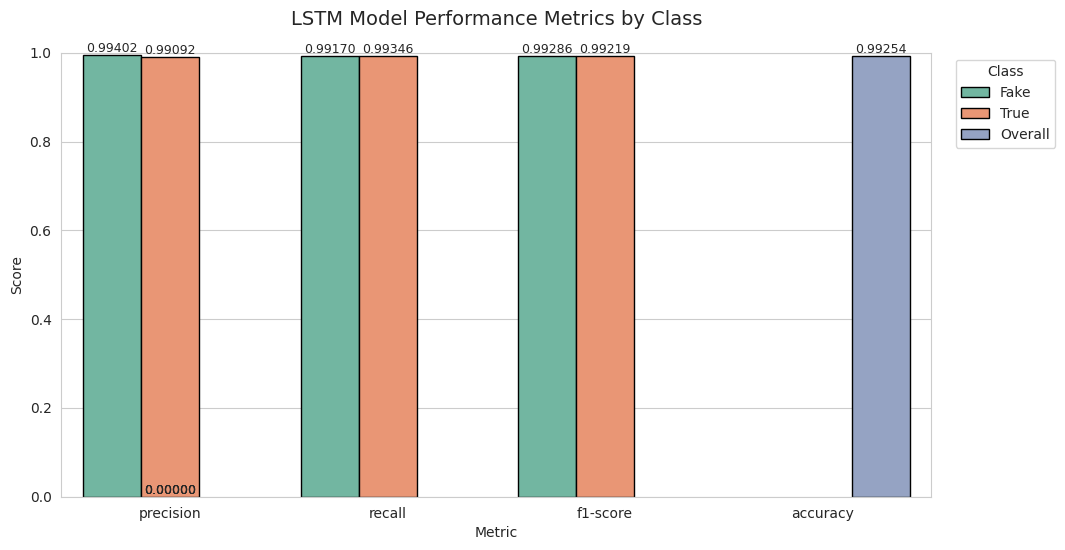

In [ ]:
plt.figure(figsize=(12,6))
sns.set_style("whitegrid")

bar_plot = sns.barplot(
    x='Metric',
    y='Score',
    hue='Class',
    data=metrics_df,
    palette='Set2',
    edgecolor='black'
)

for p in bar_plot.patches:
    height = p.get_height()
    bar_plot.annotate(
        f'{height:.5f}',
        (p.get_x() + p.get_width()/2., height),
        ha='center', va='bottom', fontsize=9
    )

plt.ylim(0,1)
plt.title("LSTM Model Performance Metrics by Class", fontsize=14, pad=20)
plt.ylabel("Score")
plt.xlabel("Metric")

plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title='Class')
plt.subplots_adjust(right=0.85, top=0.85)

plt.show()


In [ ]:
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)


Accuracy: 0.9925389755011136
Precision: 0.9565823078709078
Recall: 0.96171802054155
F1-score: 0.9591432894890001


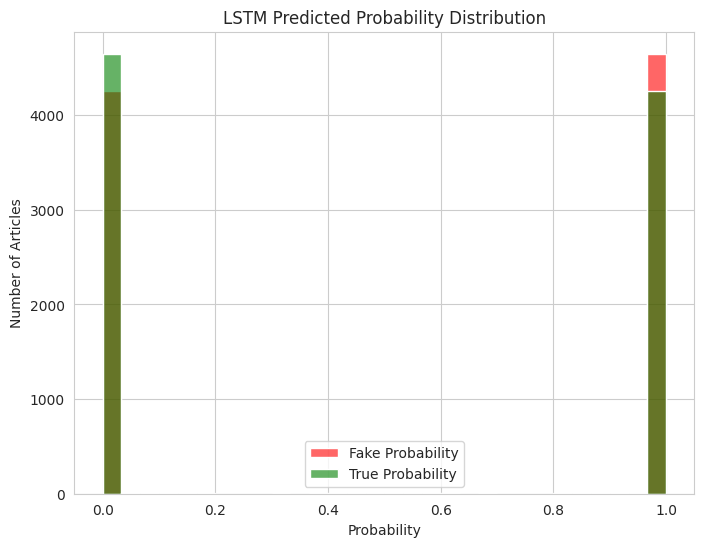

In [ ]:
plt.figure(figsize=(8,6))
sns.histplot(df_results['Prob_Fake'], bins=30, color='red', alpha=0.6, label='Fake Probability')
sns.histplot(df_results['Prob_True'], bins=30, color='green', alpha=0.6, label='True Probability')
plt.xlabel("Probability")
plt.ylabel("Number of Articles")
plt.title("LSTM Predicted Probability Distribution")
plt.legend()
plt.show()


In [ ]:
top_fake = df_results.sort_values('Prob_Fake', ascending=False).head(5)
top_true = df_results.sort_values('Prob_True', ascending=False).head(5)

print("Top 5 Predicted Fake Articles:\n", top_fake[['Text','Prob_Fake']])
print("\nTop 5 Predicted True Articles:\n", top_true[['Text','Prob_True']])


Top 5 Predicted Fake Articles:
                                                    Text  Prob_Fake
2     Because nothing says  justice  for Freddie Gra...        1.0
8979  Say what you want about the GOP but they reall...        1.0
8958  As the Democratic Party begins to unite and th...        1.0
5     Today, Senator Bernie Sanders released a new c...        1.0
7     Friday it was confirmed that the FBI is in agr...        1.0

Top 5 Predicted True Articles:
                                                    Text  Prob_True
15    WASHINGTON (Reuters) - Republican presidential...        1.0
8906  WASHINGTON (Reuters) - U.S. President Donald T...        1.0
20    WASHINGTON (Reuters) - The U.S. Senate Budget ...        1.0
6858  WASHINGTON (Reuters) - U.S. Republican Senator...        1.0
1407  WASHINGTON (Reuters) - U.S. President Donald T...        1.0


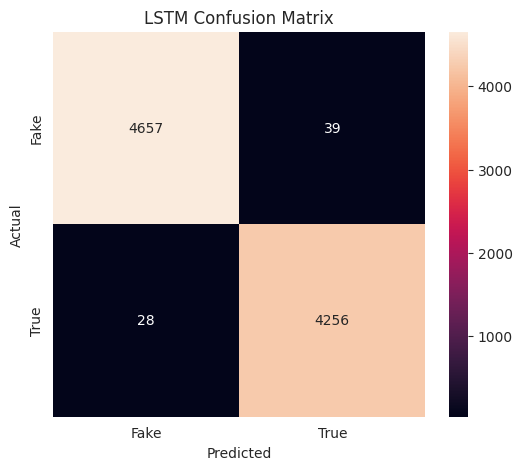

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=['Fake','True'], yticklabels=['Fake','True'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("LSTM Confusion Matrix")
plt.show()


SVM
________________________________________________________________

In [ ]:
from google.colab import files
import pandas as pd

df_fake = files.upload()
df_true = files.upload()

fake = pd.read_csv(list(df_fake.keys())[0])
true = pd.read_csv(list(df_true.keys())[0])

fake['Label'] = 'Fake'
true['Label'] = 'True'

df = pd.concat([fake, true], axis=0).sample(frac=1, random_state=42).reset_index(drop=True)
print("Dataset shape:", df.shape)
df.head()


Saving Fake.csv to Fake.csv


Saving True.csv to True.csv
Dataset shape: (44898, 5)


,title,text,subject,date,Label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",US_News,"February 13, 2017",Fake
1,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,"April 5, 2017",True
2,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,politicsNews,"September 27, 2017",True
3,OOPS: Trump Just Accidentally Confirmed He Le...,"On Monday, Donald Trump once again embarrassed...",News,"May 22, 2017",Fake
4,Donald Trump heads for Scotland to reopen a go...,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",politicsNews,"June 24, 2016",True


In [ ]:
import re

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['text'] = df['text'].apply(clean_text)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    df['text'], df['Label'], test_size=0.2, random_state=42, stratify=df['Label']
)


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=10000, stop_words='english')
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)


In [ ]:
from sklearn.decomposition import TruncatedSVD

svd = TruncatedSVD(n_components=300)
X_train_reduced = svd.fit_transform(X_train_vec)
X_test_reduced = svd.transform(X_test_vec)

from sklearn.svm import SVC
svm_clf = SVC(kernel='linear', probability=True, random_state=42)
svm_clf.fit(X_train_reduced, y_train)


SVC(kernel='linear', probability=True, random_state=42)

________________________________________________________

/tmp/ipython-input-1129017.py:36: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


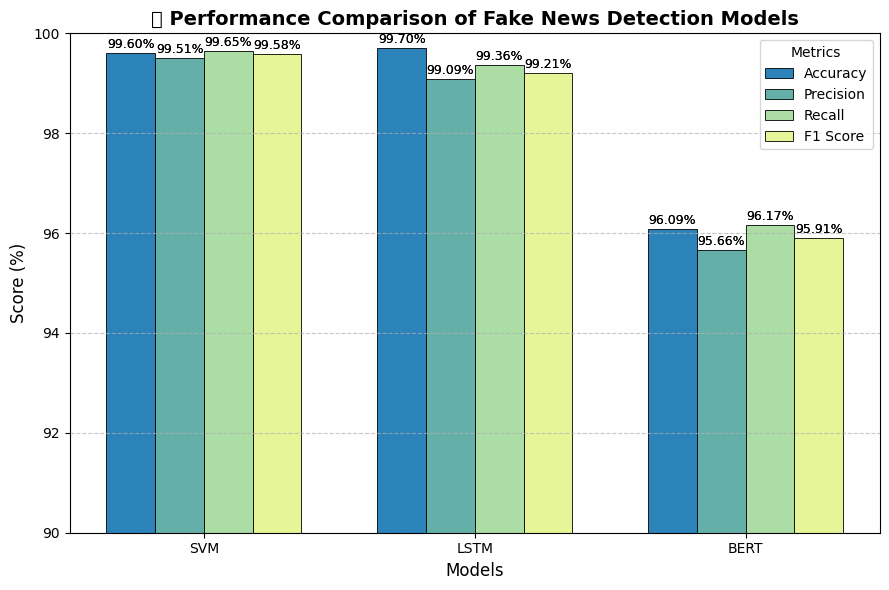

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

models = ['SVM', 'LSTM', 'BERT']

accuracy = [99.60, 99.70, 96.09]
precision = [99.51, 99.09, 95.66]
recall = [99.65, 99.36, 96.17]
f1_score = [99.58, 99.21, 95.91]

metrics = [accuracy, precision, recall, f1_score]
metric_names = ['Accuracy', 'Precision', 'Recall', 'F1 Score']

x = np.arange(len(models))
width = 0.18
colors = ['#2b83ba', '#64b0a9', '#abdda4', '#e6f598']
plt.figure(figsize=(9, 6))
for i, (metric, color) in enumerate(zip(metrics, colors)):
    bars = plt.bar(x + i*width, metric, width, label=metric_names[i], color=color, edgecolor='black', linewidth=0.6)
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + 0.1, f'{yval:.2f}%', ha='center', fontsize=9)

plt.title('📊 Performance Comparison of Fake News Detection Models', fontsize=14, fontweight='bold')
plt.xlabel('Models', fontsize=12)
plt.ylabel('Score (%)', fontsize=12)
plt.xticks(x + width*1.5, models)
plt.ylim(90, 100)
plt.legend(title='Metrics')
plt.grid(axis='y', linestyle='--', alpha=0.7)

for i, metric in enumerate(metrics):
    for j, val in enumerate(metric):
        plt.text(x[j] + i*width, val + 0.1, f'{val:.2f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.show()


In [ ]:
# ============================================
# LSTM WORKFLOW DEMONSTRATION (PROCESS ONLY)
# ============================================

# 1. Import required libraries
from google.colab import files
import pandas as pd
import numpy as np
import re
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# ------------------------------------------------
# 2. Load dataset
# ------------------------------------------------
df_fake = files.upload()
df_true = files.upload()

fake_news = pd.read_csv(list(df_fake.keys())[0])
true_news = pd.read_csv(list(df_true.keys())[0])

# Assign labels: 0 = True, 1 = Fake
true_news["label"] = 0
fake_news["label"] = 1

# Merge and shuffle
data = pd.concat([true_news, fake_news], axis=0).sample(frac=1).reset_index(drop=True)

# ------------------------------------------------
# 3. Text cleaning function
# ------------------------------------------------
def clean_text(text):
    text = text.lower()                                  # lowercase
    text = re.sub(r"http\S+", "", text)                  # remove URLs
    text = re.sub(r"[^\w\s]", "", text)                  # remove punctuation
    text = re.sub(r"\d+", "", text)                      # remove numbers
    return text

data["clean_text"] = data["text"].astype(str).apply(clean_text)

# ------------------------------------------------
# 4. Split into input (X) and output (y)
# ------------------------------------------------
X = data["clean_text"]
y = data["label"]

# ------------------------------------------------
# 5. Tokenization
# ------------------------------------------------
tokenizer = Tokenizer(num_words=20000)                   # vocab size
tokenizer.fit_on_texts(X)                                # learn word index
sequences = tokenizer.texts_to_sequences(X)              # convert to sequences

# ------------------------------------------------
# 6. Padding sequences (fix length)
# ------------------------------------------------
max_len = 300
padded_sequences = pad_sequences(sequences, maxlen=max_len)

# ------------------------------------------------
# 7. Model architecture demonstration (no training)
# ------------------------------------------------
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

model = Sequential([
    Embedding(input_dim=20000, output_dim=100, input_length=max_len),
    LSTM(128, return_sequences=False),
    Dropout(0.3),
    Dense(1, activation="sigmoid")
])

model.summary()    # Shows architecture only (no training)

# ------------------------------------------------
# 8. Sample demonstration of workflow output
# ------------------------------------------------
print("Number of samples:", len(padded_sequences))
print("Padded sequence shape:", padded_sequences.shape)
print("Vocabulary size:", len(tokenizer.word_index))
print("Workflow demonstration completed.")


Saving Fake.csv to Fake.csv


Saving True.csv to True.csv


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Number of samples: 44898
Padded sequence shape: (44898, 300)
Vocabulary size: 210475
Workflow demonstration completed.
